In [30]:
##importing packges needed for this project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
## loading our data

data = pd.read_csv("./Data/data_collected.csv")

In [32]:
#loading top 5 rows

data.head()

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.990,143.252,144.581
1,2024-01-02 15:00:00,USD,Construction Spending m/m,0.4%,1.2%,141.982,141.952,141.958,143.258,144.567
2,2024-01-03 15:00:00,USD,ISM Manufacturing PMI,47.4,46.7,143.300,143.258,143.167,144.567,144.668
3,2024-01-04 00:30:00,JPY,Final Manufacturing PMI,47.9,47.7,143.617,143.640,143.824,144.674,144.424
4,2024-01-04 12:30:00,USD,Challenger Job Cuts y/y,-20.2%,-40.8%,144.563,144.615,144.647,144.770,143.921


In [33]:
#viewing bottom 5 rows

data.tail()

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
757,2024-01-02 14:45:00,USD,Final Manufacturing PMI,49.4,48.3,141.939,141.947,141.990,143.252,144.581
758,2024-01-02 15:00:00,USD,Construction Spending m/m,0.0%,0.5%,141.982,141.952,141.958,143.258,144.567
759,2024-01-02 16:00:00,USD,Crude Oil Inventories,-1.2M,-4.2M,141.881,141.990,141.968,143.247,144.609
760,2024-01-03 15:00:00,USD,ISM Manufacturing PMI,49.3,48.4,143.300,143.258,143.167,144.567,144.668
761,2024-01-03 15:30:00,USD,Natural Gas Storage,-116B,-93B,143.241,143.244,143.247,144.578,144.673


In [34]:
## viewing the shape of the data

data.shape

#762 rows, 10 columns

(762, 10)

In [35]:
#infomation about the data

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DateTime           762 non-null    object 
 1   currency           762 non-null    object 
 2   event              762 non-null    object 
 3   actual             762 non-null    object 
 4   previous           762 non-null    object 
 5   Close_5min_before  762 non-null    float64
 6   Close_at_release   762 non-null    float64
 7   Close_5min_after   762 non-null    float64
 8   Close_24h_after    762 non-null    float64
 9   Close_48h_after    762 non-null    float64
dtypes: float64(5), object(5)
memory usage: 59.7+ KB


In [36]:
#checking for unique rows

data.value_counts()

DateTime             currency  event                        actual  previous  Close_5min_before  Close_at_release  Close_5min_after  Close_24h_after  Close_48h_after
2024-01-02 13:30:00  USD       Unemployment Claims          211K    220K      141.878            141.877           141.880           143.628          144.618            1
2024-09-02 00:30:00  JPY       Final Manufacturing PMI      49.8    49.5      145.840            145.857           145.901           146.462          145.498            1
2024-08-29 05:00:00  JPY       Consumer Confidence          36.7    36.7      144.716            144.711           144.664           145.105          146.712            1
2024-08-29 14:00:00  USD       Pending Home Sales m/m       -5.5%   4.8%      144.883            144.810           144.836           146.137          146.883            1
2024-08-29 14:30:00  USD       Natural Gas Storage          35B     35B       144.876            144.804           144.799           146.128          

In [37]:
## cheking for missing values

data.isnull().sum()

##no missing values

DateTime             0
currency             0
event                0
actual               0
previous             0
Close_5min_before    0
Close_at_release     0
Close_5min_after     0
Close_24h_after      0
Close_48h_after      0
dtype: int64

In [38]:
data.describe()

,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
count,762.000000,762.000000,762.000000,762.000000,762.000000
mean,148.790018,147.396012,148.982093,150.036665,149.434940
std,20.243744,24.721875,19.512535,15.292124,17.953536
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,147.370500,147.268500,147.412500,147.694500,147.378750
50%,151.166500,151.061000,151.161000,151.317000,151.344500
75%,155.418750,155.320500,155.432750,155.544250,155.576750
max,161.792000,161.786000,161.776000,161.871000,161.851000


In [47]:
data.corr(numeric_only=True)

,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
Close_5min_before,1.000000,0.999947,0.999917,0.982785,0.962850
Close_at_release,0.999947,1.000000,0.999954,0.982778,0.962617
Close_5min_after,0.999917,0.999954,1.000000,0.982910,0.962848
Close_24h_after,0.982785,0.982778,0.982910,1.000000,0.978659
Close_48h_after,0.962850,0.962617,0.962848,0.978659,1.000000


***O.OO close price after 48hrs is replaces the next two or 3days and if still 0, replced by nan

In [39]:
cols = [
    "Close_5min_before",
    "Close_at_release",
    "Close_5min_after",
    "Close_24h_after",
    "Close_48h_after",
    "Close_48h_after"
]

(data[cols] == 0).sum()

Close_5min_before    13
Close_at_release     20
Close_5min_after     12
Close_24h_after       7
Close_48h_after      10
Close_48h_after      10
dtype: int64

In [40]:
data.replace(
    {
        "Close_5min_before": {0: np.nan},
        "Close_at_release": {0: np.nan},
        "Close_5min_after": {0: np.nan},
        "Close_24h_after": {0: np.nan},
        "Close_48h_after": {0: np.nan},
    },
    inplace=True,
)

In [41]:
data.describe()

,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
count,749.000000,742.000000,750.000000,755.000000,752.000000
mean,151.372489,151.368950,151.365807,151.427734,151.422106
std,5.049153,5.047365,5.054160,5.009428,5.031880
min,140.560000,140.524000,140.503000,140.718000,139.787000
25%,147.700000,147.720500,147.677500,147.772500,147.719000
50%,151.295000,151.284500,151.290000,151.359000,151.410500
75%,155.482000,155.473500,155.478750,155.553000,155.652000
max,161.792000,161.786000,161.776000,161.871000,161.851000


In [42]:
data.head(20)

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.990,143.252,144.581
1,2024-01-02 15:00:00,USD,Construction Spending m/m,0.4%,1.2%,141.982,141.952,141.958,143.258,144.567
2,2024-01-03 15:00:00,USD,ISM Manufacturing PMI,47.4,46.7,143.300,143.258,143.167,144.567,144.668
3,2024-01-04 00:30:00,JPY,Final Manufacturing PMI,47.9,47.7,143.617,143.640,143.824,144.674,144.424
4,2024-01-04 12:30:00,USD,Challenger Job Cuts y/y,-20.2%,-40.8%,144.563,144.615,144.647,144.770,143.921
5,2024-01-04 13:15:00,USD,ADP Non-Farm Employment Change,164K,101K,144.598,144.642,144.690,144.817,144.065
6,2024-01-04 13:30:00,USD,Unemployment Claims,202K,220K,144.628,144.618,144.579,144.808,144.105
7,2024-01-04 14:45:00,USD,Final Services PMI,51.4,51.3,144.598,144.581,144.515,144.636,144.126
8,2024-01-04 15:30:00,USD,Natural Gas Storage,-14B,-87B,144.566,144.578,144.566,144.673,144.206
9,2024-01-04 16:00:00,USD,Crude Oil Inventories,-5.5M,-7.1M,144.585,144.609,144.593,144.763,144.135


In [48]:
data.describe()

,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
count,749.000000,742.000000,750.000000,755.000000,752.000000
mean,151.372489,151.368950,151.365807,151.427734,151.422106
std,5.049153,5.047365,5.054160,5.009428,5.031880
min,140.560000,140.524000,140.503000,140.718000,139.787000
25%,147.700000,147.720500,147.677500,147.772500,147.719000
50%,151.295000,151.284500,151.290000,151.359000,151.410500
75%,155.482000,155.473500,155.478750,155.553000,155.652000
max,161.792000,161.786000,161.776000,161.871000,161.851000


## News event analysis


In [50]:
data.head(1)

,DateTime,currency,event,actual,previous,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
0,2024-01-02 14:45:00,USD,Final Manufacturing PMI,47.9,48.2,141.939,141.947,141.99,143.252,144.581


In [51]:
data["DateTime"] = pd.to_datetime(data["DateTime"])

In [114]:
# Creating additional time features

data["Year"] = data["DateTime"].dt.year
data["Month"] = data["DateTime"].dt.month_name()
data["Month_Number"] = data["DateTime"].dt.month
data["Day"] = data["DateTime"].dt.day_name()
data["Hour"] = data["DateTime"].dt.hour

In [53]:
#no of usd vs jpy news

currency_count = data["currency"].value_counts()

print(currency_count)

currency
USD    470
JPY    292
Name: count, dtype: int64


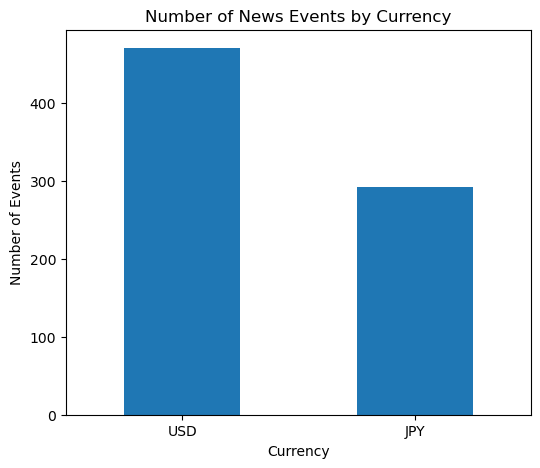

In [54]:
#visualizing the news ratio

plt.figure(figsize=(6,5))

currency_count.plot(
    kind="bar"
)

plt.title("Number of News Events by Currency")
plt.xlabel("Currency")
plt.ylabel("Number of Events")

plt.xticks(rotation=0)

plt.show()

In [55]:
## percentage distribution

currency_percentage = (
    data["currency"]
    .value_counts(normalize=True)
    *100
)

currency_percentage

currency
USD    61.67979
JPY    38.32021
Name: proportion, dtype: float64

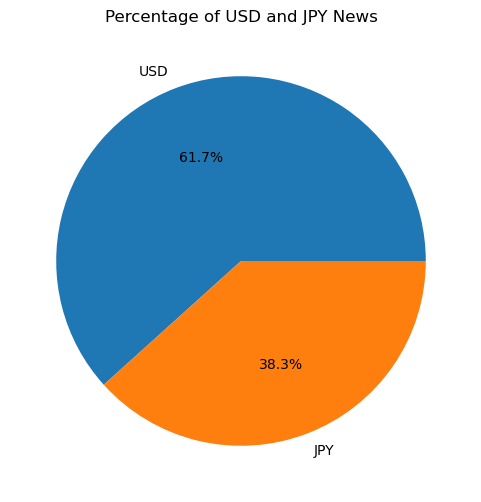

In [57]:
## vewing percentage distribution with pie chart

plt.figure(figsize=(6,6))

currency_percentage.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Percentage of USD and JPY News")

plt.show()

In [58]:
## most frequent economic news

event_frequency = (
    data["event"]
    .value_counts()
)

event_frequency.head(20)

event
Natural Gas Storage               48
Crude Oil Inventories             43
10-y Bond Auction                 24
30-y Bond Auction                 24
Final Manufacturing PMI           23
Flash Manufacturing PMI           21
Unemployment Claims               17
Tokyo Core CPI y/y                13
Economy Watchers Sentiment        12
Prelim Machine Tool Orders y/y    12
Business Inventories m/m          12
BOJ Core CPI y/y                  12
National Core CPI y/y             12
TIC Long-Term Purchases           12
Richmond Manufacturing Index      12
S&P/CS Composite-20 HPI y/y       12
Chicago PMI                       12
Bank Lending y/y                  12
Core Machinery Orders m/m         12
ADP Non-Farm Employment Change    12
Name: count, dtype: int64

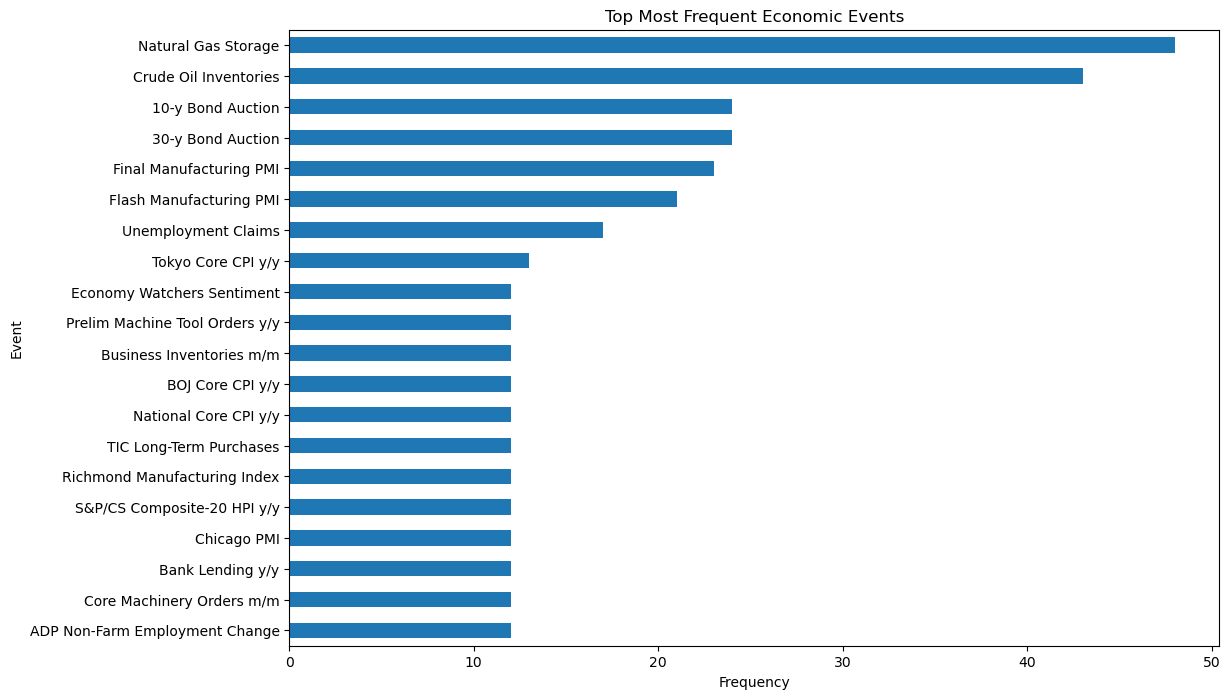

In [60]:
## viewing top frequent news

plt.figure(figsize=(12,8))

event_frequency.head(20).plot(
    kind="barh"
)

plt.title("Top Most Frequent Economic Events")

plt.xlabel("Frequency")
plt.ylabel("Event")

plt.gca().invert_yaxis()

plt.show()

In [61]:
## monthly new distribution

monthly_news = (
    data
    .groupby("Month_Number")
    .size()
)

monthly_news

Month_Number
1     68
2     59
3     61
4     61
5     67
6     65
7     64
8     65
9     63
10    67
11    59
12    63
dtype: int64

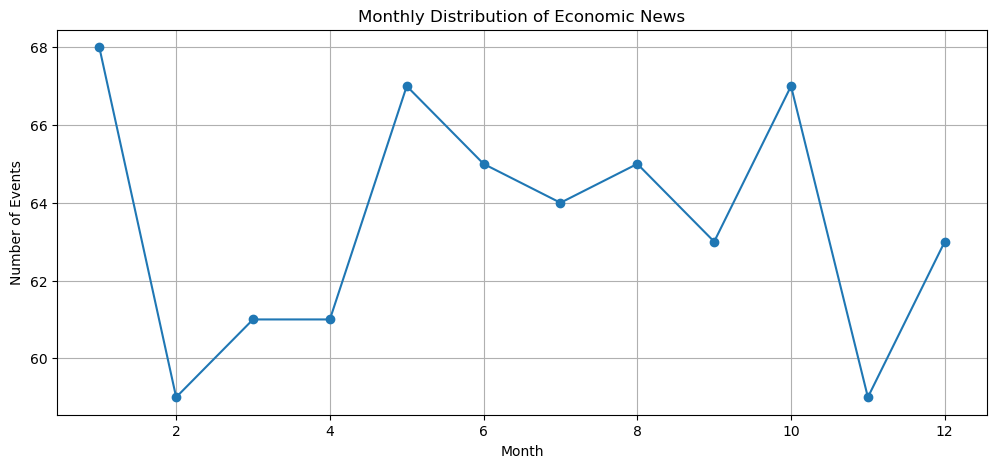

In [62]:
## visualizing this distribution

plt.figure(figsize=(12,5))

monthly_news.plot(
    marker="o"
)

plt.title("Monthly Distribution of Economic News")

plt.xlabel("Month")
plt.ylabel("Number of Events")

plt.grid(True)

plt.show()

In [63]:
## distribution by day of the week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday"
]

day_count = (
    data["Day"]
    .value_counts()
    .reindex(day_order)
)

day_count

Day
Monday        91
Tuesday      160
Wednesday    152
Thursday     235
Friday        97
Name: count, dtype: int64

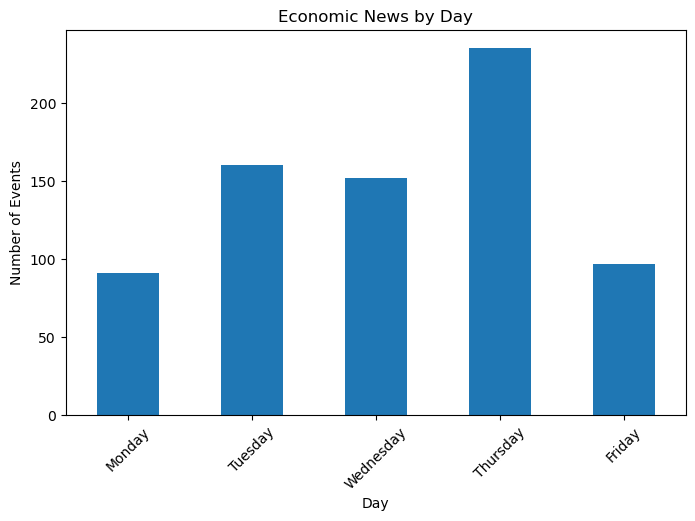

In [64]:
## visualizing 

plt.figure(figsize=(8,5))

day_count.plot(
    kind="bar"
)

plt.title("Economic News by Day")

plt.xlabel("Day")

plt.ylabel("Number of Events")

plt.xticks(rotation=45)

plt.show()

## Market price analysis

This section explore the behaviour of the USD/JPY exchange rate around economic news releases.


In [66]:
price_columns = [
    "Close_5min_before",
    "Close_at_release",
    "Close_5min_after",
    "Close_24h_after",
    "Close_48h_after"
]

In [67]:
data[price_columns].describe()

,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
count,749.000000,742.000000,750.000000,755.000000,752.000000
mean,151.372489,151.368950,151.365807,151.427734,151.422106
std,5.049153,5.047365,5.054160,5.009428,5.031880
min,140.560000,140.524000,140.503000,140.718000,139.787000
25%,147.700000,147.720500,147.677500,147.772500,147.719000
50%,151.295000,151.284500,151.290000,151.359000,151.410500
75%,155.482000,155.473500,155.478750,155.553000,155.652000
max,161.792000,161.786000,161.776000,161.871000,161.851000


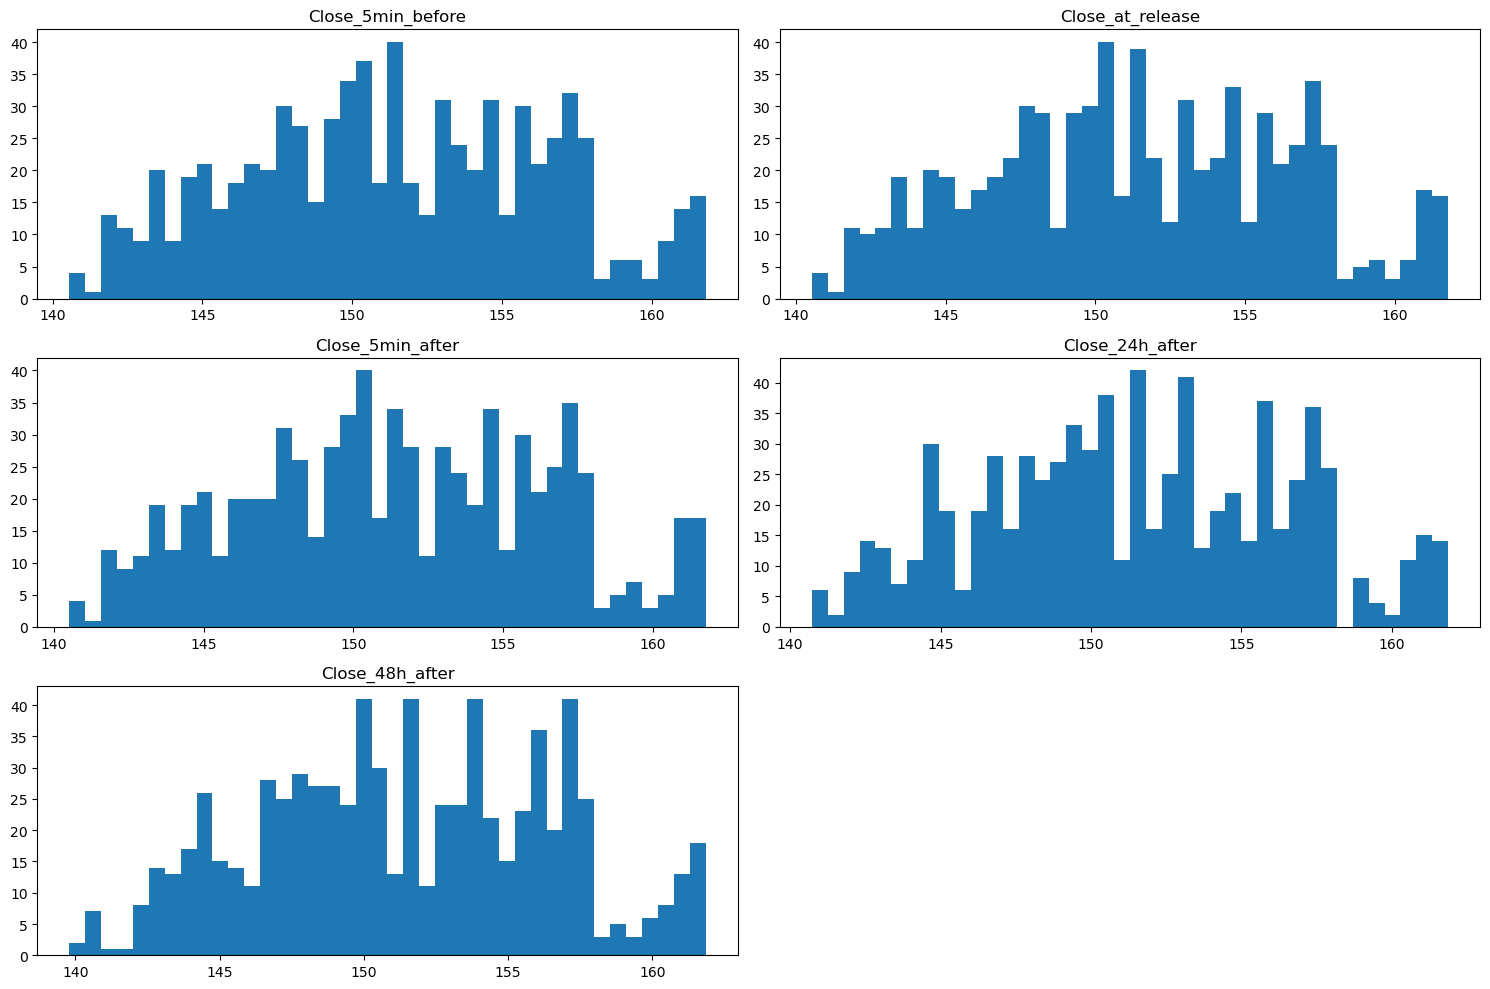

In [68]:
##price distribution

plt.figure(figsize=(15,10))

for i, column in enumerate(price_columns):

    plt.subplot(3,2,i+1)

    plt.hist(data[column], bins=40)

    plt.title(column)

plt.tight_layout()

plt.show()

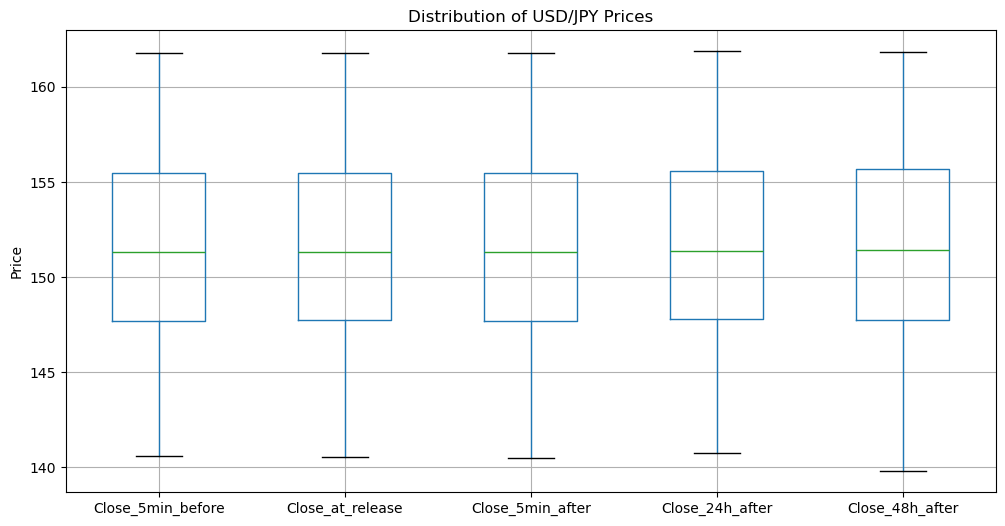

In [69]:
## box plot to detect outliers

plt.figure(figsize=(12,6))

data[price_columns].boxplot()

plt.title("Distribution of USD/JPY Prices")

plt.ylabel("Price")

plt.show()

In [71]:
## price change features 5min


data["Price_Change_5min"] = (
    data["Close_5min_after"]
    - data["Close_at_release"]
)

In [72]:
## price change features 24hrs

data["Price_Change_24h"] = (
    data["Close_24h_after"]
    - data["Close_at_release"]
)

In [73]:
## price change 48hrs

data["Price_Change_48h"] = (
    data["Close_48h_after"]
    - data["Close_at_release"]
)

In [74]:
## summary statistics

data[[
    "Price_Change_5min",
    "Price_Change_24h",
    "Price_Change_48h"
]].describe()

,Price_Change_5min,Price_Change_24h,Price_Change_48h
count,742.000000,742.000000,734.000000
mean,0.000458,0.063795,0.072685
std,0.048398,0.934234,1.380124
min,-0.236000,-4.284000,-6.455000
25%,-0.022000,-0.142750,-0.510000
50%,-0.001000,0.024500,0.157500
75%,0.022000,0.480500,0.887500
max,0.282000,3.947000,4.120000


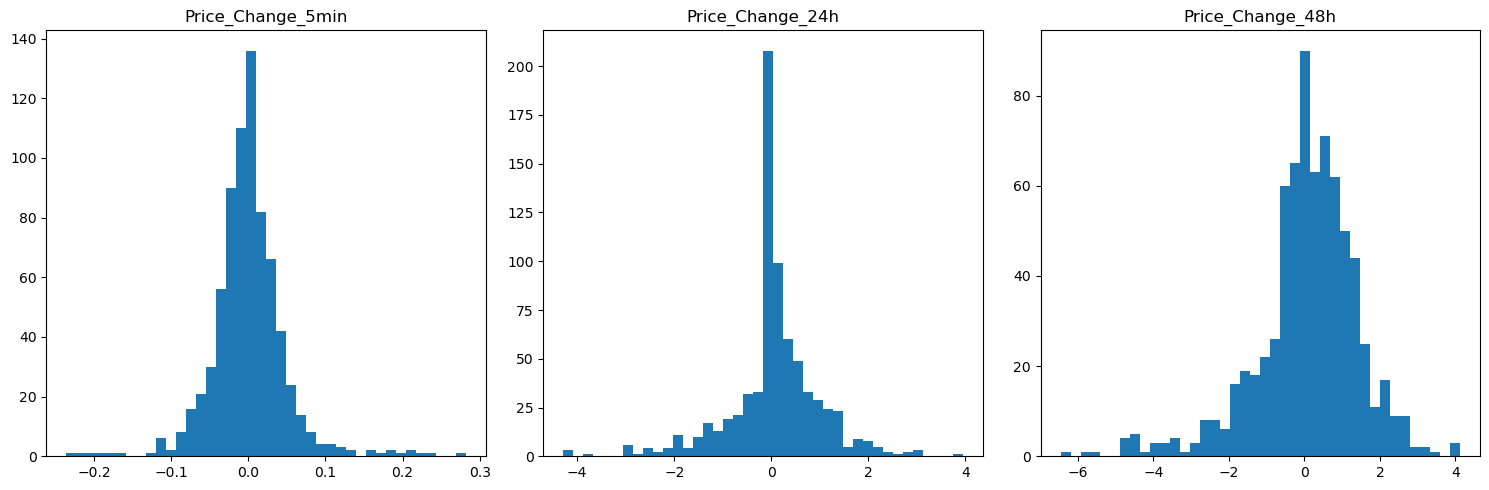

In [75]:
## viewing these changes with histogram

change_columns = [
    "Price_Change_5min",
    "Price_Change_24h",
    "Price_Change_48h"
]

plt.figure(figsize=(15,5))

for i,col in enumerate(change_columns):

    plt.subplot(1,3,i+1)

    plt.hist(data[col], bins=40)

    plt.title(col)

plt.tight_layout()

plt.show()

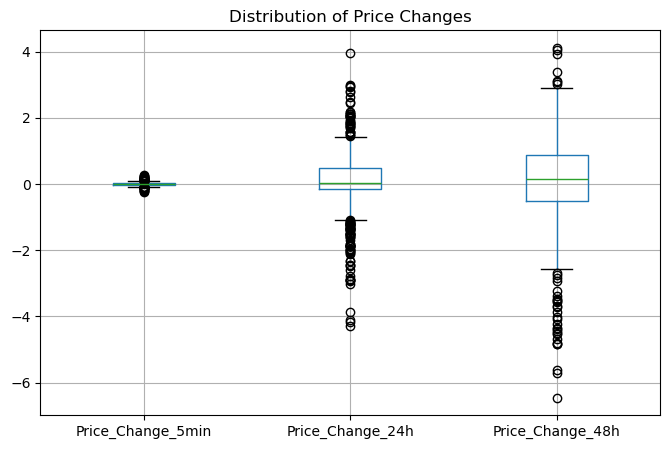

In [76]:
## box plots

plt.figure(figsize=(8,5))

data[change_columns].boxplot()

plt.title("Distribution of Price Changes")

plt.show()

In [77]:
# the absolute price changes

data["Absolute_Move_5min"] = data["Price_Change_5min"].abs()

data["Absolute_Move_24h"] = data["Price_Change_24h"].abs()

data["Absolute_Move_48h"] = data["Price_Change_48h"].abs()

In [78]:
## the summary

data["Absolute_Move_5min"] = data["Price_Change_5min"].abs()

data["Absolute_Move_24h"] = data["Price_Change_24h"].abs()

data["Absolute_Move_48h"] = data["Price_Change_48h"].abs()

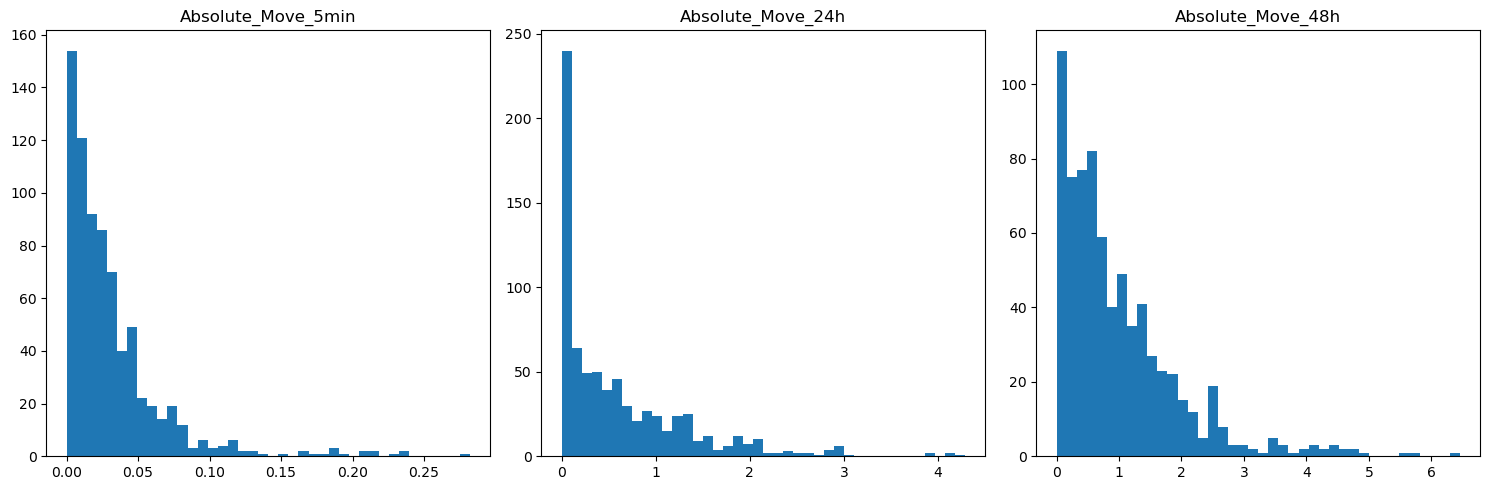

In [79]:
## the histogram

absolute_columns = [
    "Absolute_Move_5min",
    "Absolute_Move_24h",
    "Absolute_Move_48h"
]

plt.figure(figsize=(15,5))

for i,col in enumerate(absolute_columns):

    plt.subplot(1,3,i+1)

    plt.hist(data[col], bins=40)

    plt.title(col)

plt.tight_layout()

plt.show()

In [80]:
## average close price 


average_prices = data[price_columns].mean()

average_prices

Close_5min_before    151.372489
Close_at_release     151.368950
Close_5min_after     151.365807
Close_24h_after      151.427734
Close_48h_after      151.422106
dtype: float64

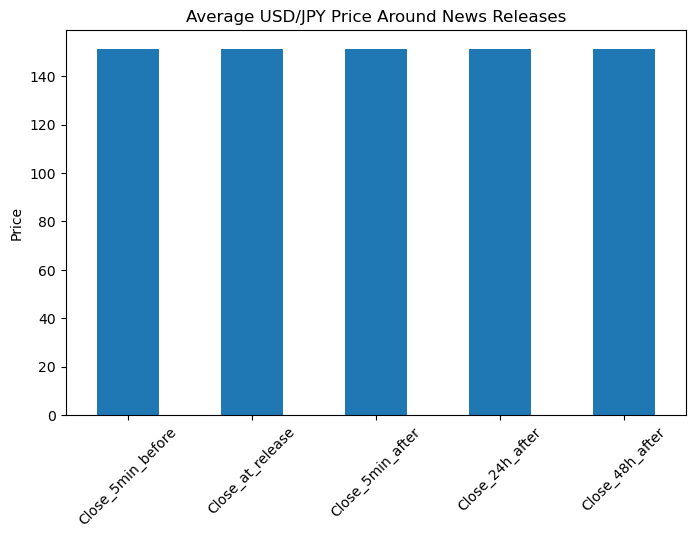

In [81]:
## average price plot


plt.figure(figsize=(8,5))

average_prices.plot(
    kind="bar"
)

plt.title("Average USD/JPY Price Around News Releases")

plt.ylabel("Price")

plt.xticks(rotation=45)

plt.show()

In [82]:
## average price change

average_change = data[change_columns].mean()

average_change

Price_Change_5min    0.000458
Price_Change_24h     0.063795
Price_Change_48h     0.072685
dtype: float64

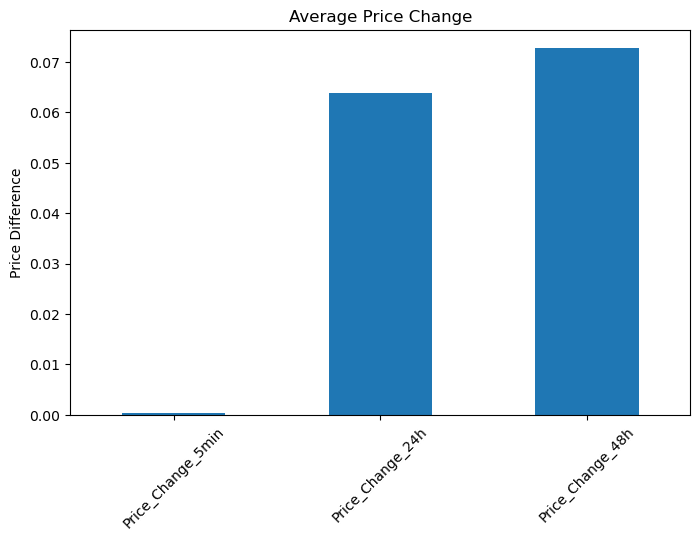

In [83]:
## viewing average price change on histogram


plt.figure(figsize=(8,5))

average_change.plot(
    kind="bar"
)

plt.title("Average Price Change")

plt.ylabel("Price Difference")

plt.xticks(rotation=45)

plt.show()

In [84]:
### largest positive move

data.nlargest(
    10,
    "Price_Change_5min"
)[[
    "DateTime",
    "currency",
    "event",
    "Price_Change_5min"
]]

,DateTime,currency,event,Price_Change_5min
248,2024-05-01 18:00:00,USD,Federal Funds Rate,0.282
397,2024-07-09 10:00:00,USD,NFIB Small Business Index,0.235
336,2024-06-12 14:30:00,USD,Crude Oil Inventories,0.230
431,2024-07-30 23:50:00,JPY,Prelim Industrial Production m/m,0.217
736,2024-12-19 02:52:00,JPY,BOJ Policy Rate,0.206
158,2024-03-19 19:00:00,USD,TIC Long-Term Purchases,0.192
405,2024-07-11 18:00:00,USD,Federal Budget Balance,0.187
3,2024-01-04 00:30:00,JPY,Final Manufacturing PMI,0.184
60,2024-01-31 15:30:00,USD,Crude Oil Inventories,0.177
157,2024-03-19 02:36:00,JPY,BOJ Policy Rate,0.163


In [85]:
## largest negative move

data.nsmallest(
    10,
    "Price_Change_5min"
)[[
    "DateTime",
    "currency",
    "event",
    "Price_Change_5min"
]]

,DateTime,currency,event,Price_Change_5min
583,2024-10-08 03:35:00,JPY,30-y Bond Auction,-0.236
456,2024-08-07 23:50:00,JPY,Bank Lending y/y,-0.213
647,2024-11-07 15:00:00,USD,Final Wholesale Inventories m/m,-0.210
437,2024-07-31 14:30:00,USD,Crude Oil Inventories,-0.186
432,2024-07-31 04:59:00,JPY,Consumer Confidence,-0.172
483,2024-08-21 14:00:00,USD,Prelim Benchmark Payrolls Revision,-0.166
542,2024-09-18 14:30:00,USD,Crude Oil Inventories,-0.132
480,2024-08-18 23:50:00,JPY,Core Machinery Orders m/m,-0.117
683,2024-11-26 14:00:00,USD,S&P/CS Composite-20 HPI y/y,-0.116
250,2024-05-02 04:59:00,JPY,Consumer Confidence,-0.115


In [86]:
## largest absolut move

data.nlargest(
    10,
    "Absolute_Move_5min"
)[[
    "DateTime",
    "currency",
    "event",
    "Absolute_Move_5min"
]]

,DateTime,currency,event,Absolute_Move_5min
248,2024-05-01 18:00:00,USD,Federal Funds Rate,0.282
583,2024-10-08 03:35:00,JPY,30-y Bond Auction,0.236
397,2024-07-09 10:00:00,USD,NFIB Small Business Index,0.235
336,2024-06-12 14:30:00,USD,Crude Oil Inventories,0.230
431,2024-07-30 23:50:00,JPY,Prelim Industrial Production m/m,0.217
456,2024-08-07 23:50:00,JPY,Bank Lending y/y,0.213
647,2024-11-07 15:00:00,USD,Final Wholesale Inventories m/m,0.210
736,2024-12-19 02:52:00,JPY,BOJ Policy Rate,0.206
158,2024-03-19 19:00:00,USD,TIC Long-Term Purchases,0.192
405,2024-07-11 18:00:00,USD,Federal Budget Balance,0.187


In [87]:
## correlation between prices


corr = data[price_columns].corr()

corr

,Close_5min_before,Close_at_release,Close_5min_after,Close_24h_after,Close_48h_after
Close_5min_before,1.000000,0.999947,0.999917,0.982785,0.962850
Close_at_release,0.999947,1.000000,0.999954,0.982778,0.962617
Close_5min_after,0.999917,0.999954,1.000000,0.982910,0.962848
Close_24h_after,0.982785,0.982778,0.982910,1.000000,0.978659
Close_48h_after,0.962850,0.962617,0.962848,0.978659,1.000000


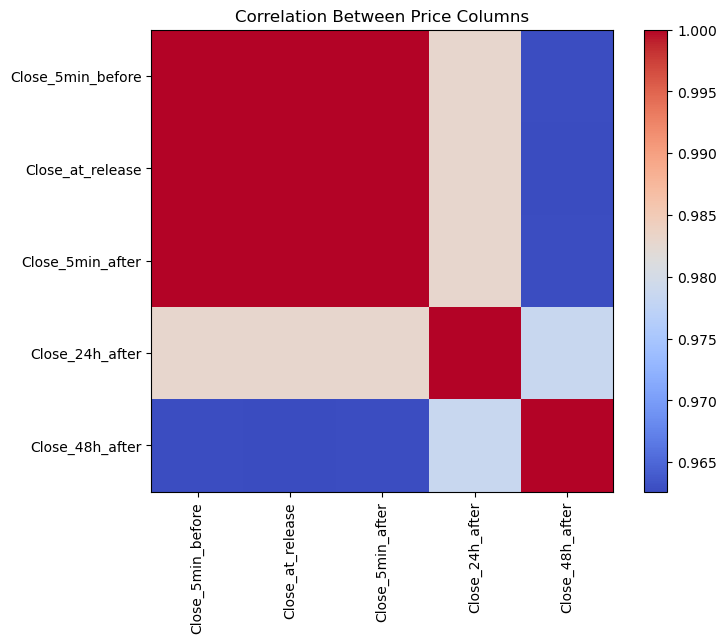

In [88]:
## correlation heatmap to view correlation between prices

plt.figure(figsize=(8,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Between Price Columns")

plt.show()

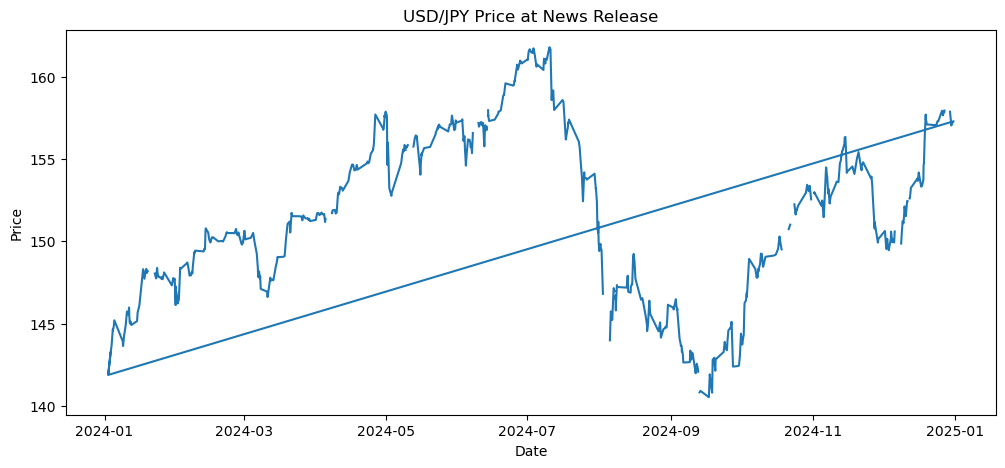

In [89]:
## price movelment timeline 


plt.figure(figsize=(12,5))

plt.plot(
    data["DateTime"],
    data["Close_at_release"]
)

plt.title("USD/JPY Price at News Release")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [90]:
## markeyt volatility approximation 


data["Volatility_5min"] = (
    data["Close_5min_after"]
    - data["Close_5min_before"]
).abs()

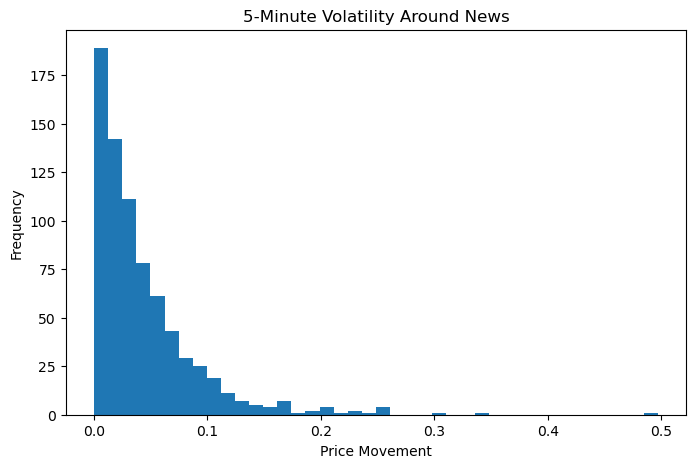

In [91]:
## its distribution


plt.figure(figsize=(8,5))

plt.hist(
    data["Volatility_5min"],
    bins=40
)

plt.title("5-Minute Volatility Around News")

plt.xlabel("Price Movement")

plt.ylabel("Frequency")

plt.show()

In [92]:
## highest volatility event


data.nlargest(
    10,
    "Volatility_5min"
)[[
    "DateTime",
    "currency",
    "event",
    "Volatility_5min"
]]

,DateTime,currency,event,Volatility_5min
549,2024-09-20 02:52:00,JPY,BOJ Policy Rate,0.497
431,2024-07-30 23:50:00,JPY,Prelim Industrial Production m/m,0.339
483,2024-08-21 14:00:00,USD,Prelim Benchmark Payrolls Revision,0.308
248,2024-05-01 18:00:00,USD,Federal Funds Rate,0.260
397,2024-07-09 10:00:00,USD,NFIB Small Business Index,0.256
437,2024-07-31 14:30:00,USD,Crude Oil Inventories,0.256
450,2024-08-06 03:35:00,JPY,10-y Bond Auction,0.254
449,2024-08-05 23:30:00,JPY,Average Cash Earnings y/y,0.245
436,2024-07-31 14:00:00,USD,Pending Home Sales m/m,0.230
157,2024-03-19 02:36:00,JPY,BOJ Policy Rate,0.229


## Event impact Analysis

Analyse how different economic news events influence the USD/JPY exchange rate by comparing the average, maximum, minimum, and volatility of price movements following each event

In [93]:
## average price movement by event 5min


event_impact_5min = (
    data.groupby("event")["Absolute_Move_5min"]
    .mean()
    .sort_values(ascending=False)
)

event_impact_5min.head(20)

event
Prelim Benchmark Payrolls Revision    0.166000
BOJ Policy Rate                       0.125500
Federal Funds Rate                    0.066000
TIC Long-Term Purchases               0.064727
Federal Budget Balance                0.064429
Consumer Confidence                   0.061667
Import Prices m/m                     0.059000
Current Account                       0.055500
NFIB Small Business Index             0.051583
Final Wholesale Inventories m/m       0.048778
Revised Industrial Production m/m     0.048182
Bank Lending y/y                      0.047750
S&P/CS Composite-20 HPI y/y           0.047000
BOJ Core CPI y/y                      0.045833
ISM Services PMI                      0.043091
Capital Spending q/y                  0.043000
Crude Oil Inventories                 0.041500
ISM Manufacturing PMI                 0.041000
30-y Bond Auction                     0.040316
Leading Indicators                    0.038250
Name: Absolute_Move_5min, dtype: float64

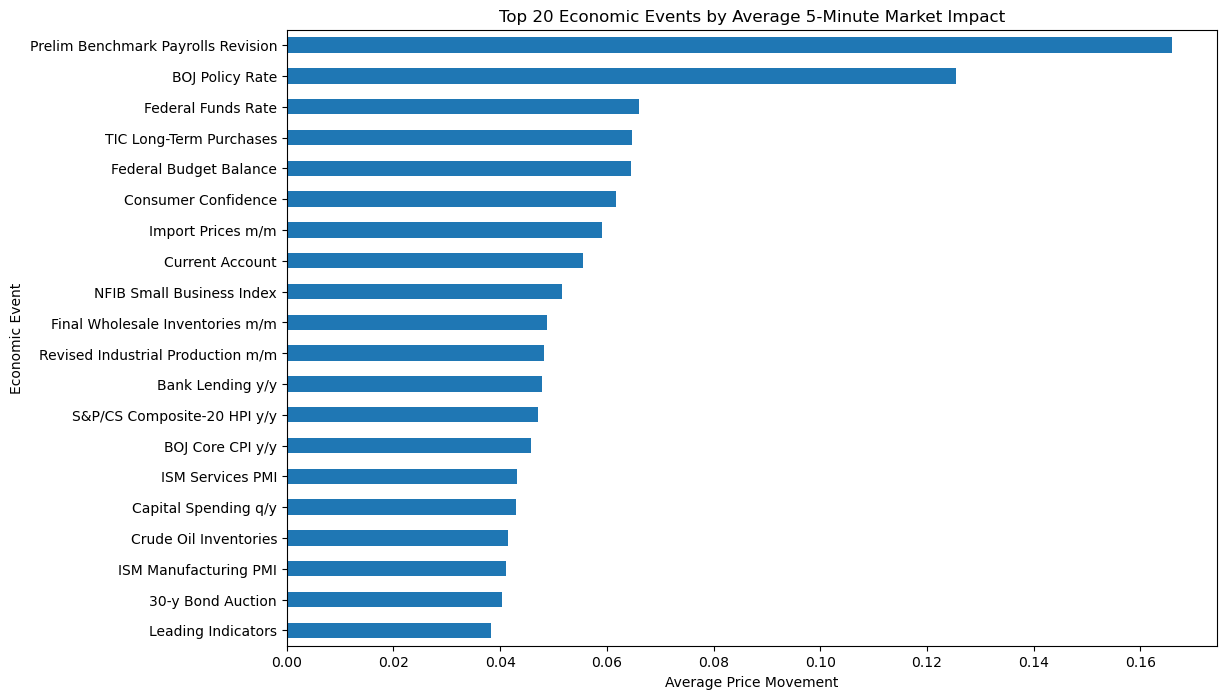

In [94]:
## top most impactful event 5min

plt.figure(figsize=(12,8))

event_impact_5min.head(20).plot(
    kind="barh"
)

plt.title("Top 20 Economic Events by Average 5-Minute Market Impact")

plt.xlabel("Average Price Movement")

plt.ylabel("Economic Event")

plt.gca().invert_yaxis()

plt.show()

In [95]:
## average 24hr market impack


event_impact_24h = (
    data.groupby("event")["Absolute_Move_24h"]
    .mean()
    .sort_values(ascending=False)
)

event_impact_24h.head(20)

event
Building Permits                      1.977000
Prelim Benchmark Payrolls Revision    1.387000
NAHB Housing Market Index             1.364000
Construction Spending m/m             1.306000
Prelim GDP q/q                        1.276500
ISM Manufacturing PMI                 1.273750
Final Manufacturing PMI               1.129304
Final GDP q/q                         1.041500
RCM/TIPP Economic Optimism            1.005333
Empire State Manufacturing Index      0.889000
ISM Services PMI                      0.884909
Challenger Job Cuts y/y               0.875857
Monetary Base y/y                     0.842364
S&P/CS Composite-20 HPI y/y           0.839250
Crude Oil Inventories                 0.829095
Final Services PMI                    0.827500
Richmond Manufacturing Index          0.817455
Federal Funds Rate                    0.811625
Mortgage Delinquencies                0.795500
Unemployment Claims                   0.786588
Name: Absolute_Move_24h, dtype: float64

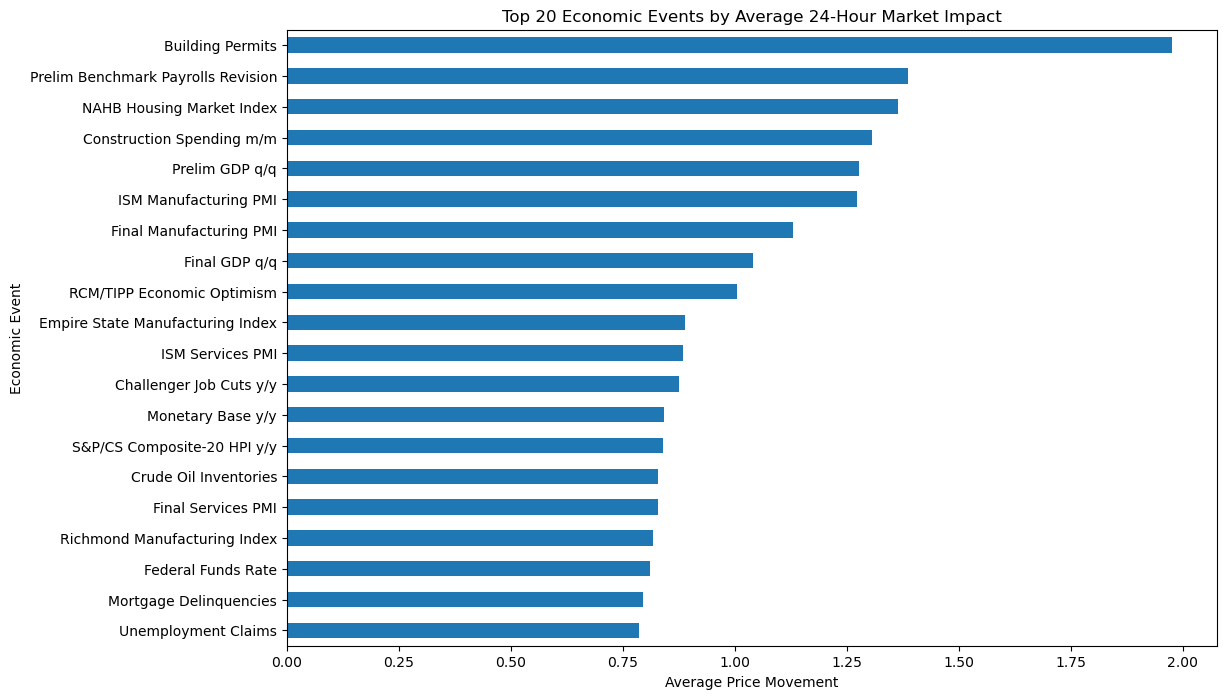

In [97]:
## viewing the top 20 economic news event by avrage 24-hr market impact 

plt.figure(figsize=(12,8))

event_impact_24h.head(20).plot(
    kind="barh"
)

plt.title("Top 20 Economic Events by Average 24-Hour Market Impact")

plt.xlabel("Average Price Movement")

plt.ylabel("Economic Event")

plt.gca().invert_yaxis()

plt.show()

In [98]:
## average 48hr market impact

event_impact_48h = (
    data.groupby("event")["Absolute_Move_48h"]
    .mean()
    .sort_values(ascending=False)
)

event_impact_48h.head(20)

event
Construction Spending m/m         2.615000
NAHB Housing Market Index         2.004000
Factory Orders m/m                1.884667
Chicago PMI                       1.832900
Final Manufacturing PMI           1.799524
Capacity Utilization Rate         1.748800
Building Permits                  1.722500
Mortgage Delinquencies            1.711500
ISM Manufacturing PMI             1.706917
Monetary Base y/y                 1.555727
ADP Non-Farm Employment Change    1.501417
Unemployment Rate                 1.475833
Federal Funds Rate                1.465375
Prelim GDP q/q                    1.405000
CB Consumer Confidence            1.377600
S&P/CS Composite-20 HPI y/y       1.352091
PPI y/y                           1.315143
RCM/TIPP Economic Optimism        1.298500
Core PPI m/m                      1.212800
Crude Oil Inventories             1.196214
Name: Absolute_Move_48h, dtype: float64

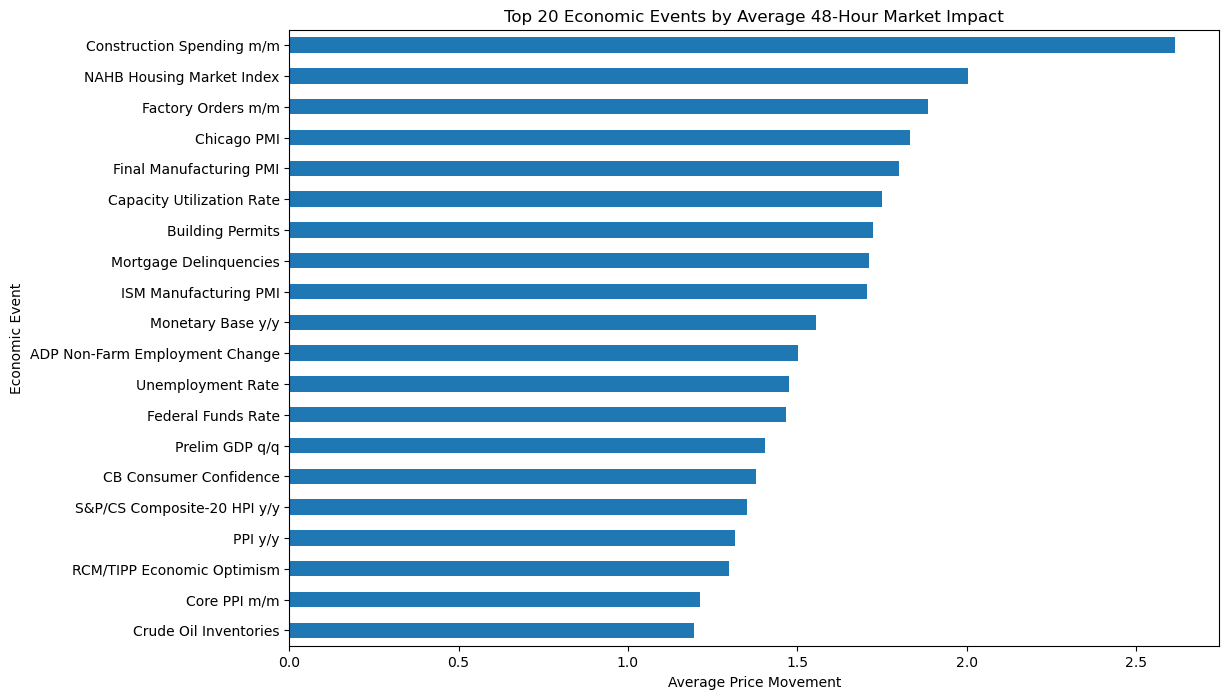

In [100]:
## 

plt.figure(figsize=(12,8))

event_impact_48h.head(20).plot(
    kind="barh"
)

plt.title("Top 20 Economic Events by Average 48-Hour Market Impact")

plt.xlabel("Average Price Movement")

plt.ylabel("Economic Event")

plt.gca().invert_yaxis()

plt.show()

In [101]:
## average market movement by currency

currency_impact = (
    data.groupby("currency")[[
        "Absolute_Move_5min",
        "Absolute_Move_24h",
        "Absolute_Move_48h"
    ]]
    .mean()
)

currency_impact

,Absolute_Move_5min,Absolute_Move_24h,Absolute_Move_48h
currency,,,
JPY,0.032774,0.518394,0.921003
USD,0.031284,0.662878,1.042892


In [102]:
##top 10 usd event


usd_events = (
    data[data["currency"]=="USD"]
    .groupby("event")["Absolute_Move_5min"]
    .mean()
    .sort_values(ascending=False)
)

usd_events.head(10)

event
Prelim Benchmark Payrolls Revision    0.166000
Federal Funds Rate                    0.066000
TIC Long-Term Purchases               0.064727
Federal Budget Balance                0.064429
Import Prices m/m                     0.059000
NFIB Small Business Index             0.051583
Final Wholesale Inventories m/m       0.048778
S&P/CS Composite-20 HPI y/y           0.047000
ISM Services PMI                      0.043091
Crude Oil Inventories                 0.041500
Name: Absolute_Move_5min, dtype: float64

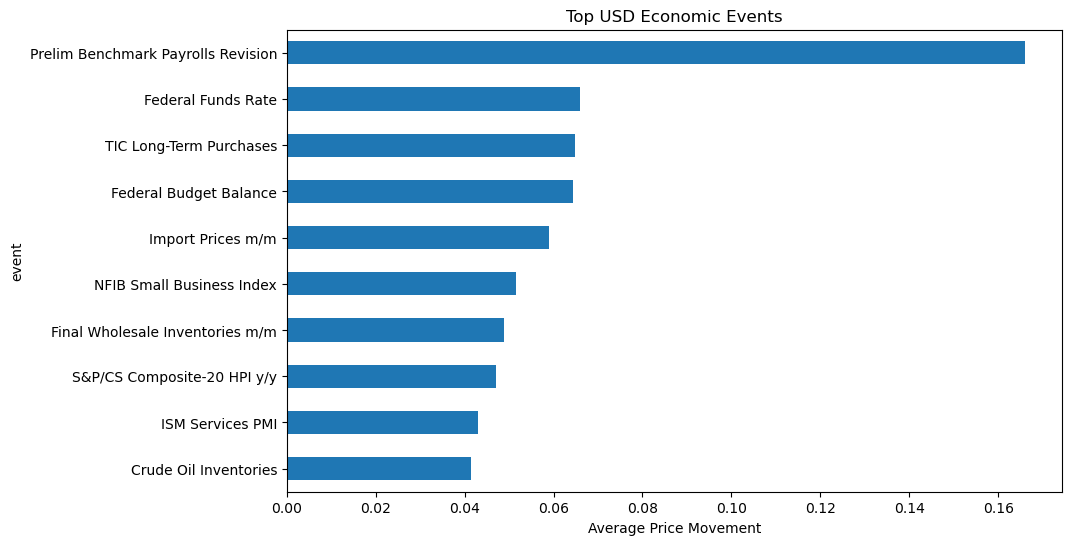

In [103]:
## plot

plt.figure(figsize=(10,6))

usd_events.head(10).plot(
    kind="barh"
)

plt.title("Top USD Economic Events")

plt.xlabel("Average Price Movement")

plt.gca().invert_yaxis()

plt.show()

In [104]:
## top 10 jpy event


jpy_events = (
    data[data["currency"]=="JPY"]
    .groupby("event")["Absolute_Move_5min"]
    .mean()
    .sort_values(ascending=False)
)

jpy_events.head(10)

event
BOJ Policy Rate                      0.125500
Consumer Confidence                  0.061667
Current Account                      0.055500
Revised Industrial Production m/m    0.048182
Bank Lending y/y                     0.047750
BOJ Core CPI y/y                     0.045833
30-y Bond Auction                    0.044583
Capital Spending q/y                 0.043000
Leading Indicators                   0.038250
Prelim Industrial Production m/m     0.037300
Name: Absolute_Move_5min, dtype: float64

In [105]:
## 


jpy_events = (
    data[data["currency"]=="JPY"]
    .groupby("event")["Absolute_Move_5min"]
    .mean()
    .sort_values(ascending=False)
)

jpy_events.head(10)

event
BOJ Policy Rate                      0.125500
Consumer Confidence                  0.061667
Current Account                      0.055500
Revised Industrial Production m/m    0.048182
Bank Lending y/y                     0.047750
BOJ Core CPI y/y                     0.045833
30-y Bond Auction                    0.044583
Capital Spending q/y                 0.043000
Leading Indicators                   0.038250
Prelim Industrial Production m/m     0.037300
Name: Absolute_Move_5min, dtype: float64

In [106]:
## maximum market movement

largest_moves = (
    data.groupby("event")[[
        "Absolute_Move_5min",
        "Absolute_Move_24h",
        "Absolute_Move_48h"
    ]]
    .max()
    .sort_values(
        by="Absolute_Move_5min",
        ascending=False
    )
)

largest_moves.head(20)

,Absolute_Move_5min,Absolute_Move_24h,Absolute_Move_48h
event,,,
Federal Funds Rate,0.282,2.991,3.564
30-y Bond Auction,0.236,1.501,1.742
NFIB Small Business Index,0.235,1.289,2.476
Crude Oil Inventories,0.230,4.171,4.440
Prelim Industrial Production m/m,0.217,2.909,2.929
Bank Lending y/y,0.213,1.233,1.662
Final Wholesale Inventories m/m,0.210,0.691,1.412
BOJ Policy Rate,0.206,1.247,1.186
TIC Long-Term Purchases,0.192,0.993,1.382


In [107]:
## most volatile event

volatility = (
    data.groupby("event")["Volatility_5min"]
    .mean()
    .sort_values(ascending=False)
)

volatility.head(20)

event
Prelim Benchmark Payrolls Revision    0.308000
BOJ Policy Rate                       0.222000
Import Prices m/m                     0.111000
Capital Spending q/y                  0.093000
Federal Budget Balance                0.083125
TIC Long-Term Purchases               0.080636
ISM Manufacturing PMI                 0.073250
Federal Funds Rate                    0.068375
Challenger Job Cuts y/y               0.064571
Revised Nonfarm Productivity q/q      0.064000
Revised Industrial Production m/m     0.062636
BOJ Core CPI y/y                      0.062417
Current Account                       0.061000
10-y Bond Auction                     0.060375
Consumer Confidence                   0.060333
Prelim Industrial Production m/m      0.056900
NFIB Small Business Index             0.056833
Leading Indicators                    0.056083
30-y Bond Auction                     0.053042
Tertiary Industry Activity m/m        0.052273
Name: Volatility_5min, dtype: float64

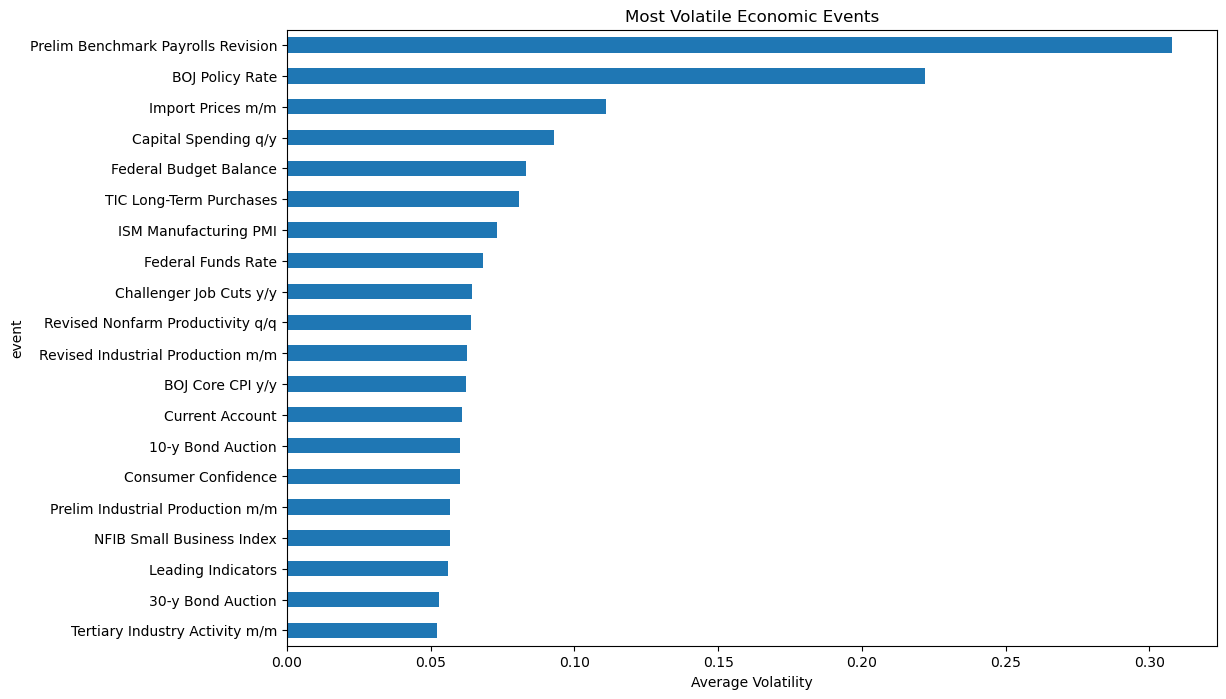

In [108]:
##plot 

plt.figure(figsize=(12,8))

volatility.head(20).plot(
    kind="barh"
)

plt.title("Most Volatile Economic Events")

plt.xlabel("Average Volatility")

plt.gca().invert_yaxis()

plt.show()

In [109]:
## create event ranking

event_summary = (
    data.groupby("event")
    .agg(
        Number_of_Events=("event","count"),
        Avg_Move_5min=("Absolute_Move_5min","mean"),
        Avg_Move_24h=("Absolute_Move_24h","mean"),
        Avg_Move_48h=("Absolute_Move_48h","mean"),
        Max_Move=("Absolute_Move_48h","max")
    )
    .sort_values(
        by="Avg_Move_5min",
        ascending=False
    )
)

event_summary.head(20)

,Number_of_Events,Avg_Move_5min,Avg_Move_24h,Avg_Move_48h,Max_Move
event,,,,,
Prelim Benchmark Payrolls Revision,1,0.166000,1.387000,0.439000,0.439
BOJ Policy Rate,4,0.125500,0.486750,0.764500,1.186
Federal Funds Rate,8,0.066000,0.811625,1.465375,3.564
TIC Long-Term Purchases,12,0.064727,0.247182,0.767182,1.382
Federal Budget Balance,10,0.064429,0.635429,0.723143,1.472
Consumer Confidence,12,0.061667,0.703500,1.034833,2.065
Import Prices m/m,1,0.059000,0.059000,1.171000,1.171
Current Account,2,0.055500,0.285000,0.674500,1.304
NFIB Small Business Index,12,0.051583,0.619333,0.975833,2.476


In [111]:
##exporting event ranking

event_summary.to_csv(
    "./Data/event_impact_summary.csv"
)

print("Event impact summary exported successfully.")

Event impact summary exported successfully.


In [112]:
## top 10 largest individual reaction

largest_reactions = (
    data.nlargest(
        10,
        "Absolute_Move_5min"
    )
)

largest_reactions[[
    "DateTime",
    "currency",
    "event",
    "Absolute_Move_5min"
]]

,DateTime,currency,event,Absolute_Move_5min
248,2024-05-01 18:00:00,USD,Federal Funds Rate,0.282
583,2024-10-08 03:35:00,JPY,30-y Bond Auction,0.236
397,2024-07-09 10:00:00,USD,NFIB Small Business Index,0.235
336,2024-06-12 14:30:00,USD,Crude Oil Inventories,0.230
431,2024-07-30 23:50:00,JPY,Prelim Industrial Production m/m,0.217
456,2024-08-07 23:50:00,JPY,Bank Lending y/y,0.213
647,2024-11-07 15:00:00,USD,Final Wholesale Inventories m/m,0.210
736,2024-12-19 02:52:00,JPY,BOJ Policy Rate,0.206
158,2024-03-19 19:00:00,USD,TIC Long-Term Purchases,0.192
405,2024-07-11 18:00:00,USD,Federal Budget Balance,0.187


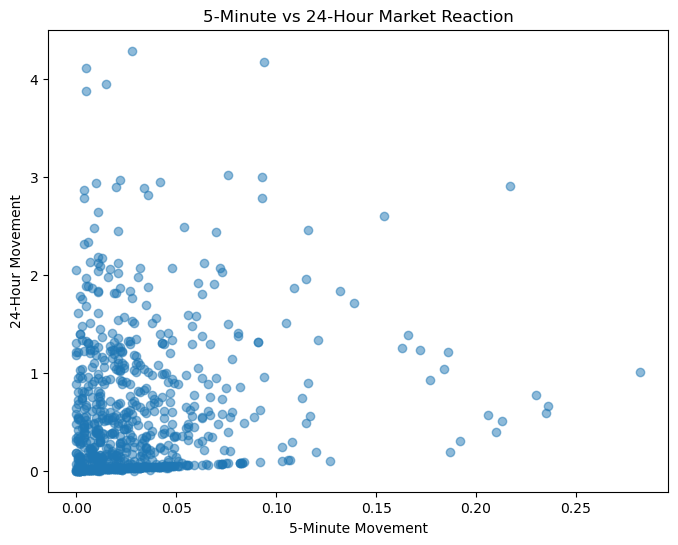

In [113]:
## relationship between 5min and 24he movement


plt.figure(figsize=(8,6))

plt.scatter(
    data["Absolute_Move_5min"],
    data["Absolute_Move_24h"],
    alpha=0.5
)

plt.xlabel("5-Minute Movement")

plt.ylabel("24-Hour Movement")

plt.title("5-Minute vs 24-Hour Market Reaction")

plt.show()